In [1]:
!pip install monai kagglehub -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 25.9 MB/s eta 0:00:00


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [3]:
import kagglehub

path = kagglehub.dataset_download("ajithdari/multi-modal-breast-cancer-dataset")
print("Path to dataset files:", path)

DATA_PATH = Path(path)

100%|██████████| 195M/195M [00:01<00:00, 131MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ajithdari/multi-modal-breast-cancer-dataset/versions/1


In [4]:
print("=== TOP LEVEL FOLDERS ===")
for item in sorted(DATA_PATH.iterdir()):
    print(f"  {item.name}/")
    if item.is_dir():
        for sub in sorted(item.iterdir()):
            print(f"    {sub.name}")
            if sub.is_dir():
                files = list(sub.iterdir())
                print(f"      ({len(files)} files)")

=== TOP LEVEL FOLDERS ===
  dataset/
    dataset1
      (3 files)
    dataset2
      (1 files)
    dataset3
      (1 files)


In [5]:
for top in sorted(DATA_PATH.iterdir()):
    for sub in sorted(top.iterdir()):
        print(f"\n=== {sub.name} ===")
        for item in sorted(sub.iterdir()):
            print(f"  {item.name}")
            if item.is_dir():
                files = list(item.iterdir())
                for f in sorted(files)[:5]:
                    print(f"    {f.name}")
                if len(files) > 5:
                    print(f"    ... ({len(files)} total)")


=== dataset1 ===
  benign
    images
    masks
  malignant
    images
    masks
  normal
    images
    masks

=== dataset2 ===
  patient_history_dataset.csv

=== dataset3 ===
  molecular_biomarker_dataset.csv


In [6]:
DATASET1 = DATA_PATH / 'dataset' / 'dataset1'
DATASET2 = DATA_PATH / 'dataset' / 'dataset2' / 'patient_history_dataset.csv'
DATASET3 = DATA_PATH / 'dataset' / 'dataset3' / 'molecular_biomarker_dataset.csv'

CLASSES = ['benign', 'malignant', 'normal']

print("Dataset 1 path:", DATASET1)
print("Dataset 2 path:", DATASET2)
print("Dataset 3 path:", DATASET3)

Dataset 1 path: /root/.cache/kagglehub/datasets/ajithdari/multi-modal-breast-cancer-dataset/versions/1/dataset/dataset1
Dataset 2 path: /root/.cache/kagglehub/datasets/ajithdari/multi-modal-breast-cancer-dataset/versions/1/dataset/dataset2/patient_history_dataset.csv
Dataset 3 path: /root/.cache/kagglehub/datasets/ajithdari/multi-modal-breast-cancer-dataset/versions/1/dataset/dataset3/molecular_biomarker_dataset.csv


In [7]:
df_clinical = pd.read_csv(DATASET2)
df_molecular = pd.read_csv(DATASET3)

print("=== CLINICAL DATA ===")
print(f"Shape: {df_clinical.shape}")
print(df_clinical.head())

print("\n=== MOLECULAR DATA ===")
print(f"Shape: {df_molecular.shape}")
print(df_molecular.head())

=== CLINICAL DATA ===
Shape: (780, 25)
  Patient ID  Age at Diagnosis Type of Breast Surgery  Cohort  \
0    MB-0002             43.19      Breast Conserving     1.0   
1    MB-0008             76.97             Mastectomy     1.0   
2    MB-0010             78.77             Mastectomy     1.0   
3    MB-0028             86.41      Breast Conserving     1.0   
4    MB-0035             84.22             Mastectomy     1.0   

  ER status measured by IHC ER Status  Neoplasm Histologic Grade  \
0                   Positve  Positive                        3.0   
1                   Positve  Positive                        3.0   
2                   Positve  Positive                        3.0   
3                   Positve  Positive                        3.0   
4                  Negative  Positive                        2.0   

  HER2 status measured by SNP6 HER2 Status Tumor Other Histologic Subtype  \
0                      Neutral    Negative                     Ductal/NST   
1      

In [8]:
print("=== CLINICAL COLUMNS ===")
print(df_clinical.dtypes)
print("\nNull values:\n", df_clinical.isnull().sum())

print("\n=== MOLECULAR COLUMNS ===")
print(df_molecular.dtypes)
print("\nNull values:\n", df_molecular.isnull().sum())

=== CLINICAL COLUMNS ===
Patient ID                         object
Age at Diagnosis                  float64
Type of Breast Surgery             object
Cohort                            float64
ER status measured by IHC          object
ER Status                          object
Neoplasm Histologic Grade         float64
HER2 status measured by SNP6       object
HER2 Status                        object
Tumor Other Histologic Subtype     object
Hormone Therapy                    object
Inferred Menopausal State          object
Primary Tumor Laterality           object
Lymph nodes examined positive     float64
Tumor Size                        float64
Tumor Stage                       float64
Mutation Count                    float64
Nottingham prognostic index       float64
Overall Survival (Months)         float64
Overall Survival Status            object
Relapse Free Status (Months)      float64
Relapse Free Status                object
Sex                                object
Patient's

In [9]:
image_counts = {}

for cls in CLASSES:
    img_dir = DATASET1 / cls / 'images'
    mask_dir = DATASET1 / cls / 'masks'
    imgs = list(img_dir.glob('*.png')) + list(img_dir.glob('*.jpg'))
    masks = list(mask_dir.glob('*.png')) + list(mask_dir.glob('*.jpg'))
    image_counts[cls] = {'images': len(imgs), 'masks': len(masks)}
    print(f"{cls}: {len(imgs)} images, {len(masks)} masks")

print(f"\nTotal images: {sum(v['images'] for v in image_counts.values())}")

benign: 437 images, 437 masks
malignant: 210 images, 210 masks
normal: 133 images, 133 masks

Total images: 780


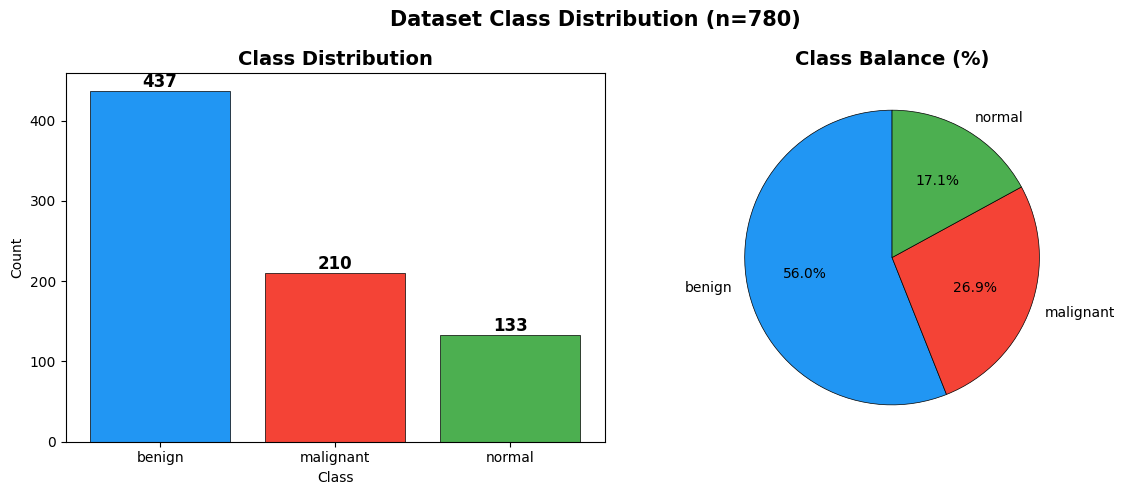

Class imbalance ratio (benign:malignant): 2.08:1
Note: Dataset is imbalanced — will need class weights or oversampling in models


In [10]:
class_counts = pd.Series({'benign': 437, 'malignant': 210, 'normal': 133})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#2196F3', '#F44336', '#4CAF50']

axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=12)

axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'black', 'linewidth': 0.5})
axes[1].set_title('Class Balance (%)', fontsize=14, fontweight='bold')

plt.suptitle('Dataset Class Distribution (n=780)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Class imbalance ratio (benign:malignant): {437/210:.2f}:1")
print("Note: Dataset is imbalanced — will need class weights or oversampling in models")

=== IMAGE RESOLUTION STATS ===
          width                                                   height  \
          count   mean    std    min    25%    50%    75%     max  count   
class                                                                      
benign     50.0  613.5  120.9  349.0  551.2  564.0  686.8  1010.0   50.0   
malignant  50.0  597.2  122.9  233.0  552.5  560.5  647.5  1048.0   50.0   
normal     50.0  668.5  133.6  393.0  557.0  648.5  765.8   928.0   50.0   

                                                           
            mean   std    min    25%    50%    75%    max  
class                                                      
benign     499.8  76.8  328.0  465.0  471.0  570.8  703.0  
malignant  493.5  56.9  339.0  463.0  478.0  528.2  612.0  
normal     546.5  89.4  310.0  470.2  565.0  598.0  712.0  


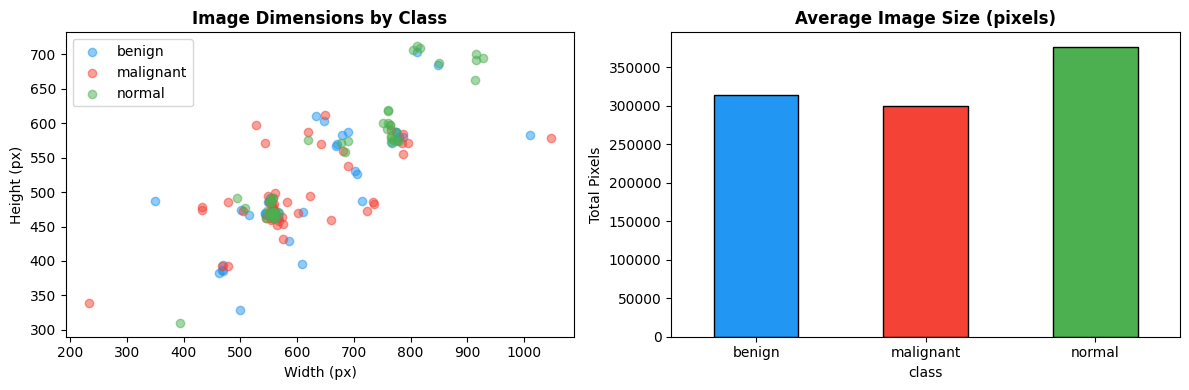

In [11]:
widths, heights, classes_list = [], [], []

for cls in CLASSES:
    img_dir = DATASET1 / cls / 'images'
    imgs = list(img_dir.glob('*.png')) + list(img_dir.glob('*.jpg'))
    for img_path in imgs[:50]:
        img = Image.open(img_path)
        widths.append(img.size[0])
        heights.append(img.size[1])
        classes_list.append(cls)

df_sizes = pd.DataFrame({'width': widths, 'height': heights, 'class': classes_list})

print("=== IMAGE RESOLUTION STATS ===")
print(df_sizes.groupby('class')[['width', 'height']].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for cls, color in zip(CLASSES, colors):
    subset = df_sizes[df_sizes['class'] == cls]
    axes[0].scatter(subset['width'], subset['height'], alpha=0.5, label=cls, color=color)
axes[0].set_title('Image Dimensions by Class', fontweight='bold')
axes[0].set_xlabel('Width (px)')
axes[0].set_ylabel('Height (px)')
axes[0].legend()

df_sizes['pixels'] = df_sizes['width'] * df_sizes['height']
df_sizes.groupby('class')['pixels'].mean().plot(kind='bar', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_title('Average Image Size (pixels)', fontweight='bold')
axes[1].set_ylabel('Total Pixels')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('image_resolutions.png', dpi=150, bbox_inches='tight')
plt.show()

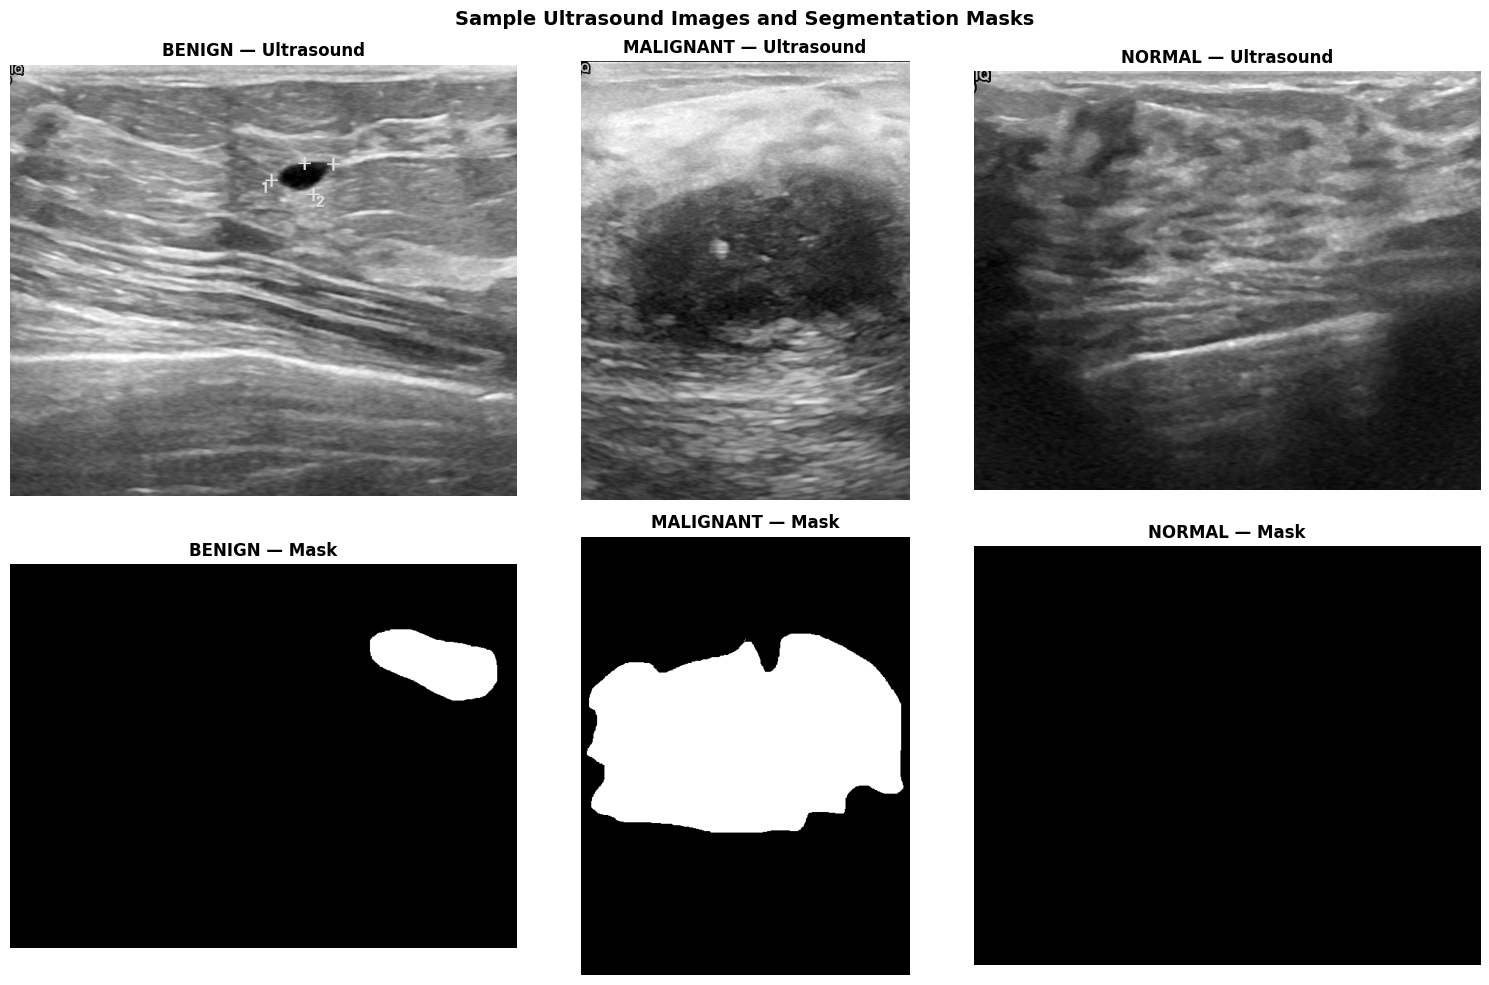

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, cls in enumerate(CLASSES):
    img_dir = DATASET1 / cls / 'images'
    mask_dir = DATASET1 / cls / 'masks'

    imgs = sorted(list(img_dir.glob('*.png')) + list(img_dir.glob('*.jpg')))
    masks = sorted(list(mask_dir.glob('*.png')) + list(mask_dir.glob('*.jpg')))

    img = Image.open(imgs[0]).convert('L')
    mask = Image.open(masks[0]).convert('L')

    axes[0][i].imshow(img, cmap='gray')
    axes[0][i].set_title(f'{cls.upper()} — Ultrasound', fontsize=12, fontweight='bold')
    axes[0][i].axis('off')

    axes[1][i].imshow(mask, cmap='gray')
    axes[1][i].set_title(f'{cls.upper()} — Mask', fontsize=12, fontweight='bold')
    axes[1][i].axis('off')

plt.suptitle('Sample Ultrasound Images and Segmentation Masks', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

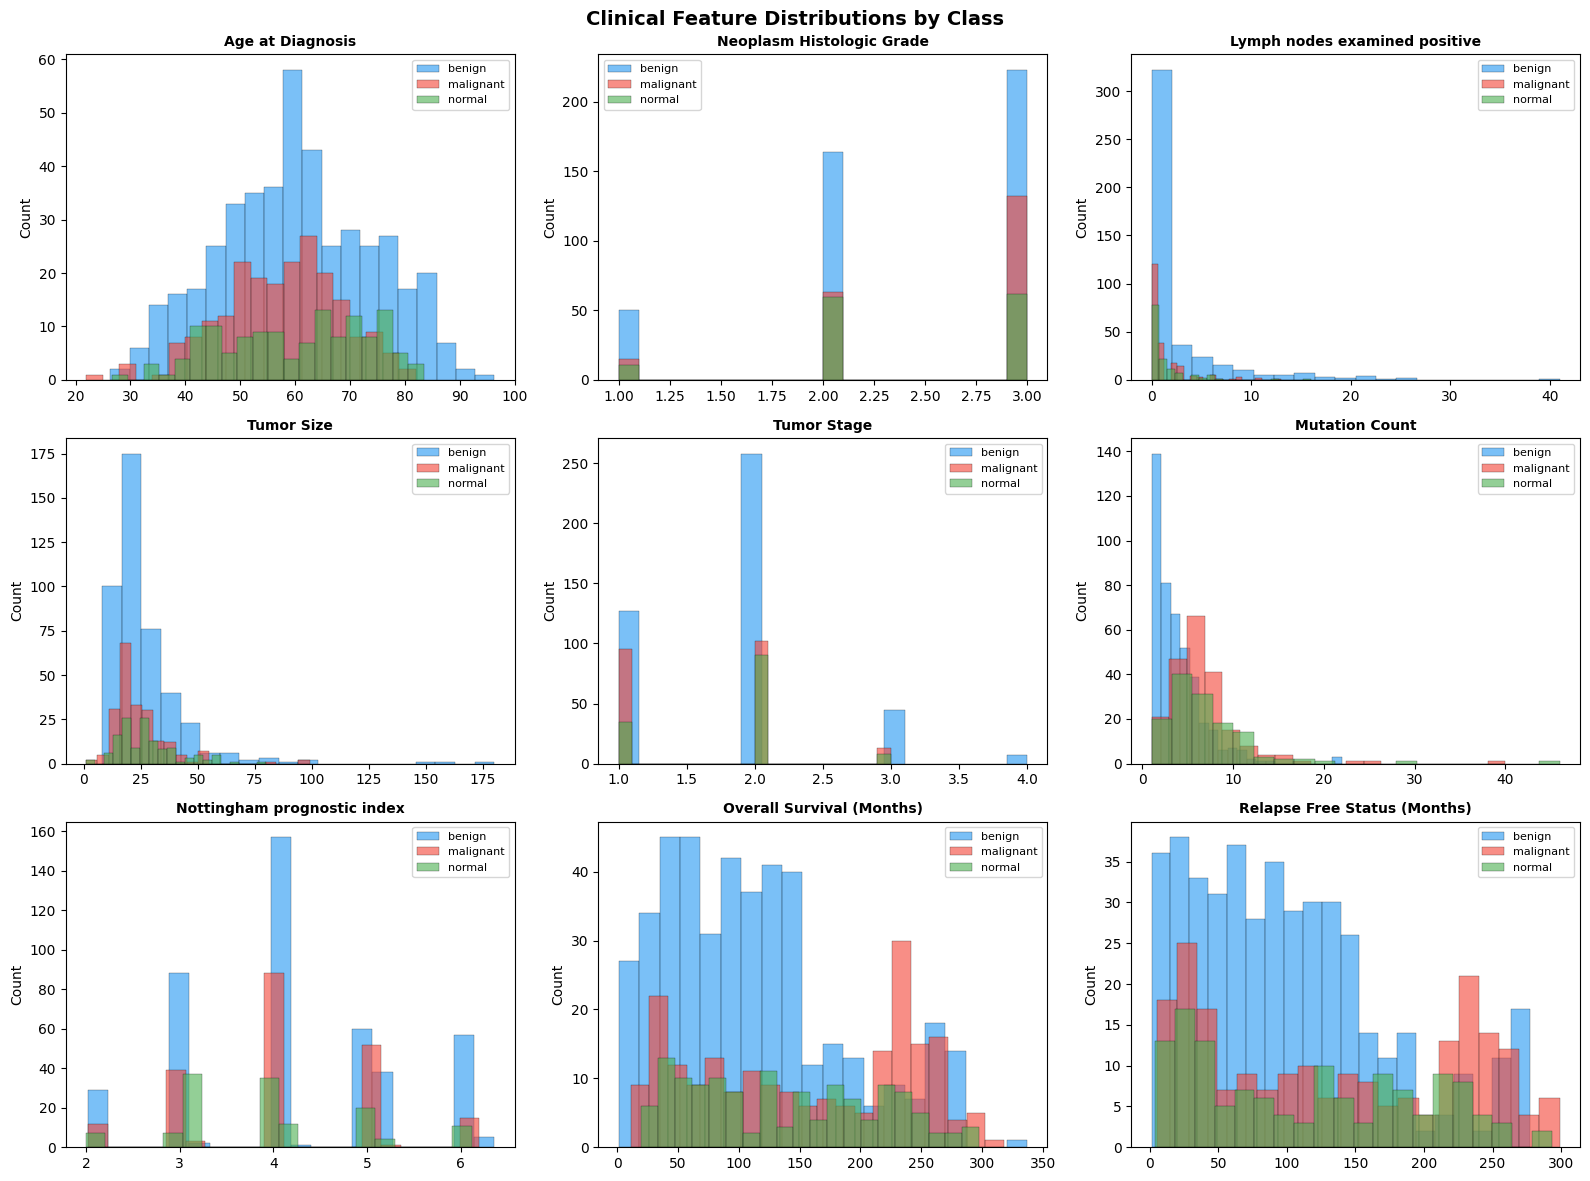

In [13]:
numerical_cols = ['Age at Diagnosis', 'Neoplasm Histologic Grade', 'Lymph nodes examined positive',
                  'Tumor Size', 'Tumor Stage', 'Mutation Count',
                  'Nottingham prognostic index', 'Overall Survival (Months)',
                  'Relapse Free Status (Months)']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    for cls, color in zip(CLASSES, colors):
        subset = df_clinical[df_clinical['class'] == cls][col].dropna()
        axes[i].hist(subset, alpha=0.6, label=cls, color=color, bins=20, edgecolor='black', linewidth=0.3)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('Count')

plt.suptitle('Clinical Feature Distributions by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('clinical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

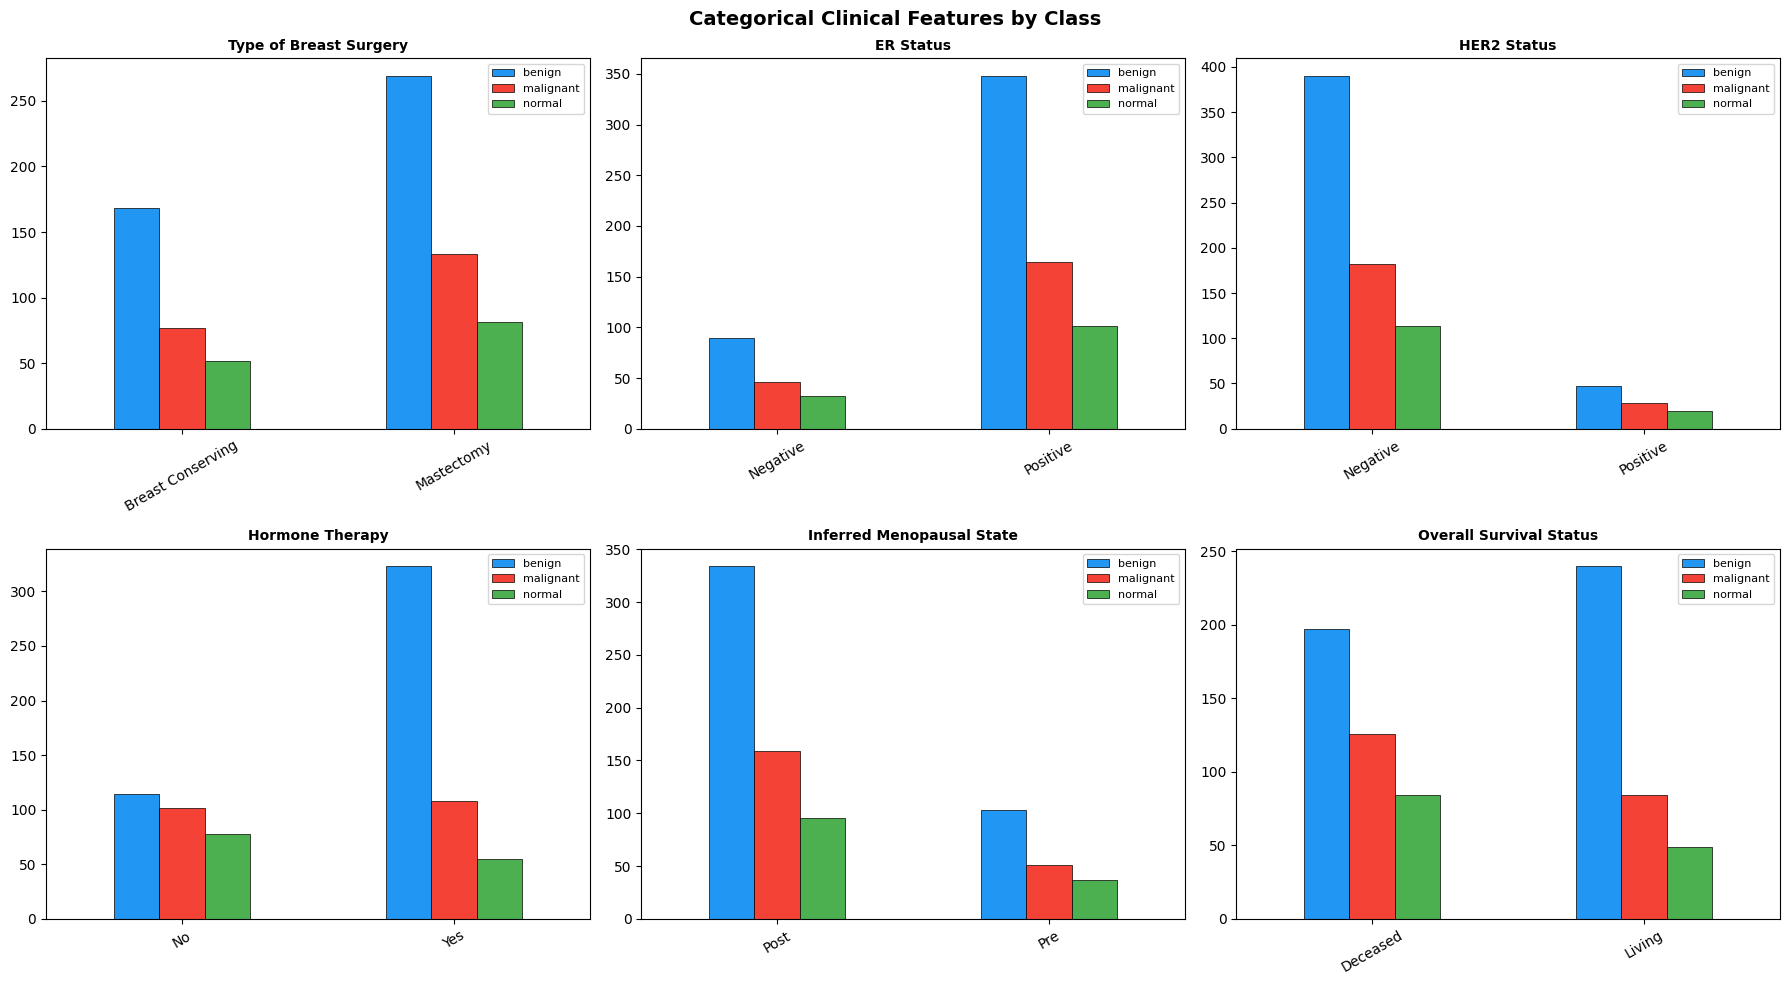

In [14]:
categorical_cols = ['Type of Breast Surgery', 'ER Status', 'HER2 Status',
                    'Hormone Therapy', 'Inferred Menopausal State', 'Overall Survival Status']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ct = pd.crosstab(df_clinical[col], df_clinical['class'])
    ct.plot(kind='bar', ax=axes[i], color=colors, edgecolor='black', linewidth=0.5)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(fontsize=8)

plt.suptitle('Categorical Clinical Features by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_features.png', dpi=150, bbox_inches='tight')
plt.show()

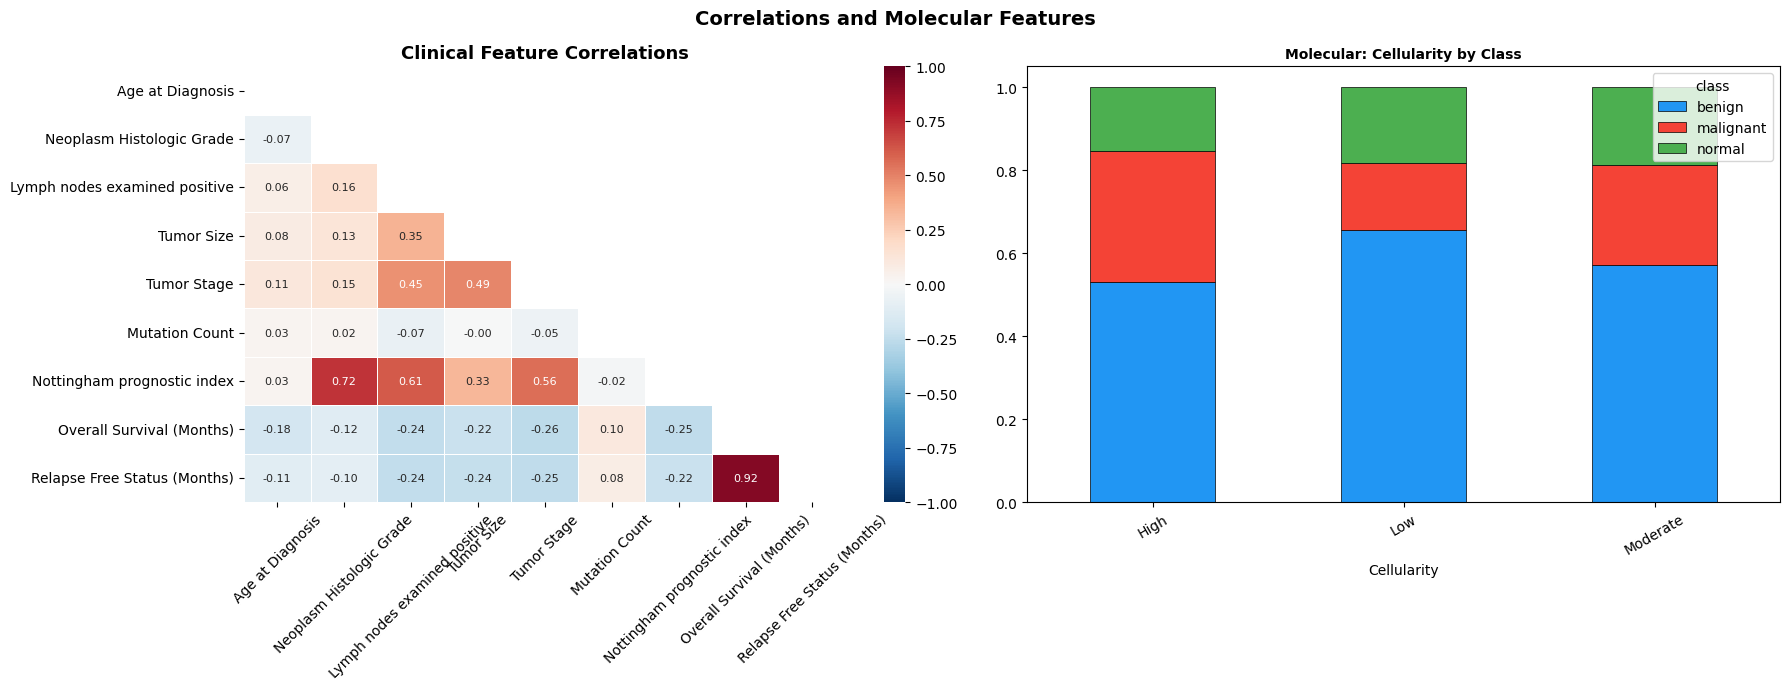

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

corr = df_clinical[numerical_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=axes[0],
            linewidths=0.5, annot_kws={'size': 8})
axes[0].set_title('Clinical Feature Correlations', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

mol_cols = ['Cellularity', 'Chemotherapy', 'Pam50 + Claudin-low subtype', 'PR Status']
df_merged = df_clinical.merge(df_molecular, on='Patient ID')

for col in mol_cols:
    ct = pd.crosstab(df_merged[col], df_merged['class'])
    ct_pct = ct.div(ct.sum(axis=1), axis=0)
    ct_pct.plot(kind='bar', ax=axes[1], color=colors, edgecolor='black', linewidth=0.5,
                stacked=True)
    axes[1].set_title(f'Molecular: {col} by Class', fontsize=10, fontweight='bold')
    axes[1].tick_params(axis='x', rotation=30)
    break

plt.suptitle('Correlations and Molecular Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlations_molecular.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
print("=" * 55)
print("         DATASET SUMMARY — TASK 1")
print("=" * 55)
print(f"Total patients:          {len(df_clinical)}")
print(f"Benign cases:            437 ({437/780*100:.1f}%)")
print(f"Malignant cases:         210 ({210/780*100:.1f}%)")
print(f"Normal cases:            133 ({133/780*100:.1f}%)")
print(f"Total images:            780 (+ 780 masks)")
print(f"Missing values:          0 (both CSVs)")
print(f"Clinical features:       {df_clinical.shape[1]-2} (excl. ID + class)")
print(f"Molecular features:      {df_molecular.shape[1]-1} (excl. ID)")
print(f"Image modality:          Ultrasound (grayscale)")
print(f"Imbalance ratio:         benign:malignant = {437/210:.1f}:1")
print("=" * 55)

print("\nClass distribution:")
print(df_clinical['class'].value_counts())

print("\nSurgery types:")
print(df_clinical['Type of Breast Surgery'].value_counts())

print("\nER Status breakdown:")
print(df_clinical['ER Status'].value_counts())

         DATASET SUMMARY — TASK 1
Total patients:          780
Benign cases:            437 (56.0%)
Malignant cases:         210 (26.9%)
Normal cases:            133 (17.1%)
Total images:            780 (+ 780 masks)
Missing values:          0 (both CSVs)
Clinical features:       23 (excl. ID + class)
Molecular features:      9 (excl. ID)
Image modality:          Ultrasound (grayscale)
Imbalance ratio:         benign:malignant = 2.1:1

Class distribution:
class
benign       437
malignant    210
normal       133
Name: count, dtype: int64

Surgery types:
Type of Breast Surgery
Mastectomy           483
Breast Conserving    297
Name: count, dtype: int64

ER Status breakdown:
ER Status
Positive    613
Negative    167
Name: count, dtype: int64
